In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder: compress image to latent vector
        self.encoder = nn.Sequential(
            nn.Flatten(),                     # (1, 28, 28) → (784)
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 16)                 # Latent vector size = 16
        )

        # Decoder: reconstruct image from latent vector
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),                     # Output pixel values between 0 and 1
            nn.Unflatten(1, (1, 28, 28))      # (784) → (1, 28, 28)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
for epoch in range(epochs):
    for images, _ in loader:
        images = images.to(device)
        
        noise = torch.randn_like(images) * 1 + 5
        noisy_images = images + noise
        noisy_images = torch.clamp(noisy_images, 0., 1.)
        
        outputs = model(noisy_images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
print("Training finished.\n")

Epoch [1/50], Loss: 0.0317
Epoch [2/50], Loss: 0.0217
Epoch [3/50], Loss: 0.0216
Epoch [4/50], Loss: 0.0155
Epoch [5/50], Loss: 0.0161
Epoch [6/50], Loss: 0.0139
Epoch [7/50], Loss: 0.0143
Epoch [8/50], Loss: 0.0113
Epoch [9/50], Loss: 0.0135
Epoch [10/50], Loss: 0.0116
Epoch [11/50], Loss: 0.0113
Epoch [12/50], Loss: 0.0122
Epoch [13/50], Loss: 0.0127
Epoch [14/50], Loss: 0.0108
Epoch [15/50], Loss: 0.0109
Epoch [16/50], Loss: 0.0101
Epoch [17/50], Loss: 0.0118
Epoch [18/50], Loss: 0.0097
Epoch [19/50], Loss: 0.0104
Epoch [20/50], Loss: 0.0114
Epoch [21/50], Loss: 0.0105
Epoch [22/50], Loss: 0.0105
Epoch [23/50], Loss: 0.0105
Epoch [24/50], Loss: 0.0101
Epoch [25/50], Loss: 0.0098
Epoch [26/50], Loss: 0.0093
Epoch [27/50], Loss: 0.0093
Epoch [28/50], Loss: 0.0098
Epoch [29/50], Loss: 0.0099
Epoch [30/50], Loss: 0.0101
Epoch [31/50], Loss: 0.0093
Epoch [32/50], Loss: 0.0088
Epoch [33/50], Loss: 0.0087
Epoch [34/50], Loss: 0.0094
Epoch [35/50], Loss: 0.0094
Epoch [36/50], Loss: 0.0093
E

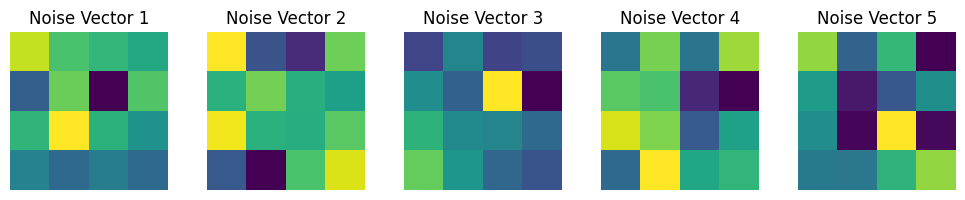

In [ ]:
noise_vectors = torch.normal(mean=5.0, std=1.0, size=(5, 16))
plt.figure(figsize=(10, 2))
for i in range(5):
    vector_image = noise_vectors[i].reshape(4, 4).cpu().numpy()
    plt.subplot(1, 5, i + 1)
    plt.imshow(vector_image)
    plt.title(f"Noise Vector {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

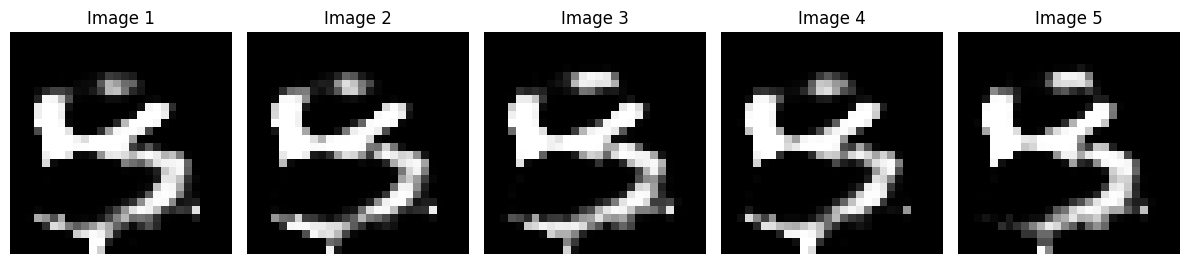

In [ ]:
noise_vectors = torch.normal(mean=5.0, std=1.0, size=(5, 16)).to(device)
with torch.no_grad():
    generated_images = model.decoder(noise_vectors).cpu()
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()
